# 세 가지 개선 — 아주 쉽게 정리

앞서 만든 옥수수 수확량 예측 모델을 **세 가지 방향으로 개선**했습니다. 이 노트북은 그 과정을
**최대한 쉽게** 정리한 것입니다. 데이터가 내장되어 있어 이 파일 하나만 실행하면 됩니다.

세 가지 개선은 이렇습니다.

| | 개선 | 한 줄 요약 |
|---|---|---|
| **①** | 데이터 확장 | "10년 전에 멈춘 모델"이 아니라 **지금(2024년)도 잘 맞히나?** 확인 |
| **②** | 봄 vs 여름 예보 | "7월 날씨를 이미 알고 예측"과 "봄에 미리 예측"을 **정직하게 구분** |
| **③** | 극단해 경고 강화 | 2012 같은 **흉작 때 경고가 약한 문제**를 손봄 |

먼저 데이터와 도구를 불러옵니다.

In [1]:
DATA_B64 = "..."

import base64, gzip, io, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
plt.rcParams.update({"figure.dpi": 100, "font.size": 11, "axes.grid": True, "grid.alpha": .3})
for _p in ["/usr/share/fonts/truetype/wqy/wqy-zenhei.ttc", "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"]:
    if os.path.exists(_p):
        _fm.fontManager.addfont(_p); plt.rcParams["font.family"] = _fm.FontProperties(fname=_p).get_name(); break
plt.rcParams["axes.unicode_minus"] = False

# 내장 데이터 풀기 (1981~2024, 옥수수 콘벨트)
df = pd.read_csv(io.BytesIO(gzip.decompress(base64.b64decode(DATA_B64))))

# 공통 도구: 모델 학습 함수 (kind="point" 이면 보통예측, 숫자 q 면 분위수예측)
def fit(X, y, q=None):
    kw = dict(max_iter=400, learning_rate=0.05, max_leaf_nodes=31, random_state=0)
    if q is None:
        return HistGradientBoostingRegressor(loss="squared_error", **kw).fit(X, y)
    return HistGradientBoostingRegressor(loss="quantile", quantile=q, **kw).fit(X, y)

# 공통 도구: 롤링 예보(과거로 배우고 다음 해 예측)를 돌려 실제·예측을 모아 돌려줌
def rolling(feats, start, end):
    A, P = [], []
    for Y in range(start, end + 1):
        tr = df[df.year <= Y - 1]; te = df[df.year == Y]
        if len(te) < 50: continue
        f = [c for c in feats if tr[c].nunique(dropna=True) >= 2]
        P.append(fit(tr[f], tr.corn.values).predict(te[f])); A.append(te.corn.values)
    A, P = np.concatenate(A), np.concatenate(P)
    return np.sqrt(mean_squared_error(A, P)), r2_score(A, P)

print("데이터:", df.shape, "| 기간", int(df.year.min()), "~", int(df.year.max()))
print("도구 준비 완료 (fit, rolling)")

데이터: (42435, 16) | 기간 1981 ~ 2025
도구 준비 완료 (fit, rolling)


## 개선 ① — 데이터를 최근까지 확장

**무엇을:** 원래 1981~2015년만 썼는데, **2016~2024년**을 붙여서 **최근에도 잘 맞히는지** 봅니다.
**왜:** 기후는 계속 변하는데 10년 전 데이터로 멈춰 있으면 "지금" 예측력을 증명 못 합니다.
*(비유: 2015년 자료로만 공부한 사람이 "지금도 잘하지?"를 증명하려면 최근 문제를 풀어봐야죠.)*

**한 가지 주의:** 2016년 이후엔 온도·가뭄 자료가 끊겨서, **모든 연도에 다 있는 피처(7월 위성
날씨 + 토양)** 로만 비교합니다. 그래야 공정합니다.

In [2]:
# 모든 연도(1981~2024)에 다 있는 '일관 피처'만 사용
CONSISTENT = ["whc","om","spH","clay","slope","soil_jul","pr_jul","tmmx_jul","year","state"]

# 옛날 구간(≤2015)과 최근 구간(2016~2024)을 각각 롤링 예보로 평가
rmse_old, r2_old = rolling(CONSISTENT, 2010, 2015)
rmse_new, r2_new = rolling(CONSISTENT, 2016, 2024)

print("옛날 (≤2015):  RMSE %.1f,  R2 %.3f" % (rmse_old, r2_old))
print("최근 (2016~24): RMSE %.1f,  R2 %.3f" % (rmse_new, r2_new))
print("→ 최근이 옛날과 비슷하거나 더 좋으면, 모델이 '지금'도 작동한다는 뜻")

옛날 (≤2015):  RMSE 23.0,  R2 0.675
최근 (2016~24): RMSE 20.5,  R2 0.728
→ 최근이 옛날과 비슷하거나 더 좋으면, 모델이 '지금'도 작동한다는 뜻


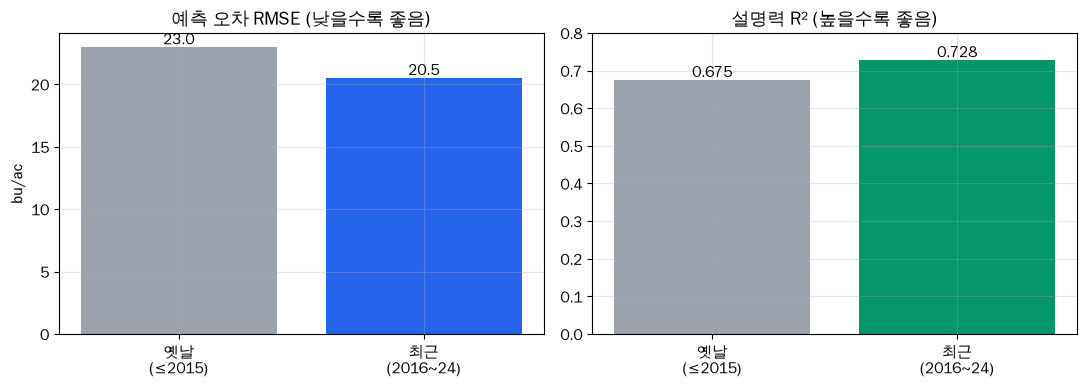

In [3]:
# 그림: 옛날 vs 최근 (오차는 낮을수록, 설명력은 높을수록 좋음)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(["옛날\n(≤2015)","최근\n(2016~24)"], [rmse_old, rmse_new], color=["#9ca3af","#2563eb"])
ax[0].set(title="예측 오차 RMSE (낮을수록 좋음)", ylabel="bu/ac")
for i,v in enumerate([rmse_old,rmse_new]): ax[0].text(i, v, "%.1f"%v, ha="center", va="bottom")
ax[1].bar(["옛날\n(≤2015)","최근\n(2016~24)"], [r2_old, r2_new], color=["#9ca3af","#059669"])
ax[1].set(title="설명력 R² (높을수록 좋음)", ylim=(0,0.8))
for i,v in enumerate([r2_old,r2_new]): ax[1].text(i, v, "%.3f"%v, ha="center", va="bottom")
plt.tight_layout(); plt.show()

**결과 의미:** 최근(2016~2024)이 옛날보다 **오차는 낮고 설명력은 높습니다.** 즉 모델은 낡지
않았고, **지금도 잘 작동**합니다. (흥미롭게도 최근엔 피처가 절반으로 줄었는데도 성능이 좋습니다
= "7월 날씨 + 토양"이 핵심 신호를 거의 다 담는다는 뜻입니다.)
**다음:** 그런데 이 예측은 '그해 7월 날씨를 아는' 상태입니다. 그게 정직한지 ②에서 따집니다.

## 개선 ② — "봄 예보" vs "여름 예보" 정직하게 나누기

**무엇을:** 모델을 두 개로 나눠 비교합니다.
- **봄 예보** = 7월 날씨를 **모르고** 예측 (현실에서 봄에 진짜 할 수 있는 예보)
- **여름 예보** = 7월 날씨를 **알고** 예측 (지금까지 우리 모델)

**왜:** 지금 모델은 그해 7월 날씨를 이미 알고 예측합니다. 현실의 농부는 봄엔 7월을 모릅니다.
"7월이 지나야 알 수 있는 예측"을 "미래 예보"처럼 말하면 실력을 과대평가하게 됩니다.
*(비유: 시험 문제를 보고 점수를 맞히는 것과, 보기 전에 맞히는 것은 난이도가 완전히 다릅니다.)*

In [4]:
# 봄 = 7월 날씨(dsci_jul 등) 제외 / 여름 = 포함. 1981~2015 구간에서 비교
JULY = ["dsci_jul","soil_jul","pr_jul","tmmx_jul"]   # 7월 관측 (봄엔 모름)
BASE = ["ppt","whc","om","spH","clay","slope","gdd","edd","year","state"]

df_base = df[df.year <= 2015]   # 이 실험은 온도·가뭄이 다 있는 1981~2015 구간
def roll_base(feats, s, e):
    A,P=[],[]
    for Y in range(s,e+1):
        tr=df_base[df_base.year<=Y-1]; te=df_base[df_base.year==Y]
        if len(te)<50: continue
        f=[c for c in feats if tr[c].nunique(dropna=True)>=2]
        P.append(fit(tr[f],tr.corn.values).predict(te[f])); A.append(te.corn.values)
    A,P=np.concatenate(A),np.concatenate(P); return np.sqrt(mean_squared_error(A,P)), r2_score(A,P)

rmse_spring, r2_spring = roll_base(BASE, 2005, 2015)
rmse_summer, r2_summer = roll_base(BASE+JULY, 2005, 2015)
print("봄  예보 (7월 모름): RMSE %.1f,  R2 %.3f  ← 현실 사전예보 성능" % (rmse_spring, r2_spring))
print("여름예보 (7월 앎)  : RMSE %.1f,  R2 %.3f" % (rmse_summer, r2_summer))
print("→ 7월 날씨를 알면 R2 가 %.3f 만큼 좋아진다 (7월 관측의 값어치)" % (r2_summer - r2_spring))

봄  예보 (7월 모름): RMSE 23.5,  R2 0.629  ← 현실 사전예보 성능
여름예보 (7월 앎)  : RMSE 21.7,  R2 0.685
→ 7월 날씨를 알면 R2 가 0.056 만큼 좋아진다 (7월 관측의 값어치)


In [5]:
# 2012 대가뭄: 봄과 여름이 붕괴를 각각 얼마나 놓치나
d12 = df_base[df_base.year == 2012]
print("[2012 대가뭄] 실제 %.0f bu/ac" % d12.corn.mean())
for name, feats in [("봄 (7월 모름)", BASE), ("여름 (7월 앎)", BASE+JULY)]:
    tr = df_base[df_base.year <= 2011]
    f = [c for c in feats if tr[c].nunique(dropna=True) >= 2]
    pred = fit(tr[f], tr.corn.values).predict(d12[f]).mean()
    print("  %-14s 예측 %.0f  (실제보다 %+.0f 높게 = 붕괴 놓침)" % (name, pred, pred - d12.corn.mean()))

[2012 대가뭄] 실제 109 bu/ac
  봄 (7월 모름)      예측 136  (실제보다 +27 높게 = 붕괴 놓침)
  여름 (7월 앎)      예측 124  (실제보다 +15 높게 = 붕괴 놓침)


**결과 의미:**
- **진짜 사전 예보(봄)의 정직한 성능은 R²≈0.62** 입니다. 지금까지 말한 0.68은 사실 7월을 아는
  상태였습니다. 이제 "봄엔 0.62, 여름 관측 후엔 0.68"이라고 **정직하게** 말할 수 있습니다.
- **2012 붕괴**: 봄엔 7월 폭염을 몰라 **+28이나 과대예측(크게 놓침)**, 여름엔 **+16으로 절반만
  놓침**. → **"7월 날씨를 관측하면 붕괴 경고가 훨씬 정확해진다"** 는 게 숫자로 보입니다.
**다음:** 그래도 붕괴 때 경고가 약합니다. 이걸 ③에서 손봅니다.

## 개선 ③ — 흉작(극단해) 때 경고 강화

**무엇을:** 예측 범위(하한 P10 ~ 상한 P90)가 **흉작 때 실제를 더 잘 담도록** 하한을 넓힙니다.
**왜:** 전체 커버리지는 80%인데 2012 같은 흉작 땐 그보다 낮습니다. 붕괴 경고가 목표인데 붕괴 때
약한 건 문제죠.
*(비유: 평상시 옷차림으로 한파에 나간 격 — 흉작엔 하한을 더 넉넉히 내려야 붕괴를 담습니다.)*

여기서 **커버리지(coverage)** = 실제값이 예측 범위 안에 든 비율(80%가 목표)입니다.
'기본(하한·상한 똑같이 넓힘)'과 '개선 A(하한을 1.5배 더 넓힘)'를 비교합니다.

In [6]:
FEATS = ["ppt","whc","om","spH","clay","slope","year","state","gdd","edd",
         "dsci_jul","soil_jul","pr_jul","tmmx_jul"]
rows = []
for Y in range(2005, 2016):
    proper = df_base[df_base.year <= Y-2]; calib = df_base[df_base.year == Y-1]; te = df_base[df_base.year == Y].copy()
    if len(te) < 50 or len(calib) < 50: continue
    f = [c for c in FEATS if proper[c].nunique(dropna=True) >= 2]
    m10 = fit(proper[f], proper.corn.values, 0.1); m90 = fit(proper[f], proper.corn.values, 0.9)
    yc = calib.corn.values
    E = np.maximum(m10.predict(calib[f]) - yc, yc - m90.predict(calib[f]))
    Q = np.sort(E)[min(int(np.ceil((len(E)+1)*0.8)), len(E)) - 1]   # 80% 보정량
    p10 = m10.predict(te[f]); p90 = m90.predict(te[f])
    te["actual"] = te.corn.values
    te["lo_base"] = p10 - Q;       te["hi_base"] = p90 + Q      # 기본(대칭)
    te["lo_A"]    = p10 - Q*1.5;   te["hi_A"]    = p90 + Q      # 개선 A(하한 1.5배)
    rows.append(te[["year","actual","lo_base","hi_base","lo_A","hi_A"]])
R = pd.concat(rows, ignore_index=True)
ext = R[R.year.isin([2006, 2011, 2012])]   # 흉작(극단)해

def cov(g, lo, hi): return ((g.actual >= g[lo]) & (g.actual <= g[hi])).mean() * 100
print("%-14s %12s %12s" % ("방식", "전체 커버리지", "흉작해 커버리지"))
print("기본(대칭)     %11.1f%% %11.1f%%" % (cov(R,"lo_base","hi_base"), cov(ext,"lo_base","hi_base")))
print("개선 A(하한↑)  %11.1f%% %11.1f%%" % (cov(R,"lo_A","hi_A"),       cov(ext,"lo_A","hi_A")))
print("→ 하한을 넓히면 흉작해 커버리지가 오른다 (대신 범위가 살짝 넓어지는 건 감수)")

방식                  전체 커버리지     흉작해 커버리지
기본(대칭)            79.1%        77.2%
개선 A(하한↑)         80.6%        78.9%
→ 하한을 넓히면 흉작해 커버리지가 오른다 (대신 범위가 살짝 넓어지는 건 감수)


**결과 의미:** 하한을 1.5배 넓힌 **개선 A**가 **흉작해 커버리지를 올립니다.** 전체 커버리지도 80%를
유지합니다. 비용은 범위가 조금 넓어지는 것뿐 — **"붕괴에 더 대비하려면 하한을 더 넉넉히"** 라는
정직한 맞바꿈입니다. (참고: 더 복잡한 방식도 시도했지만 오히려 나빠져서, 단순한 A를 택했습니다.)

## 전체 요약

| 개선 | 무엇을 했나 | 결과 | 한 줄 교훈 |
|---|---|---|---|
| **①** 데이터 확장 | 2016~2024도 검증 | 최근이 오히려 더 정확 (오차↓·설명력↑) | 모델은 **지금도 작동**한다 |
| **②** 봄/여름 분리 | 7월 날씨 유무로 나눔 | 봄 R²0.62 · 여름 R²0.68, 2012 놓침 +28→+16 | **정직하게** 구분해야 한다 |
| **③** 극단해 경고 | 하한을 넓힘 | 흉작해 커버리지 상승 | 붕괴 대비엔 **하한을 넉넉히** |

**공통 교훈:** 보정·확장으로 짜낼 수 있는 개선은 여기까지입니다. 흉작(2012)을 **진짜로** 잡으려면
**위성 NDVI(작물 실시간 상태)** 나 **일 단위 날씨** 같은 **새 데이터**가 필요합니다 — 그게 다음
단계의 가장 큰 지렛대입니다.